In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv(r"C:\Users\agraw\OneDrive\Desktop\Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [4]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [5]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.dtypes

CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

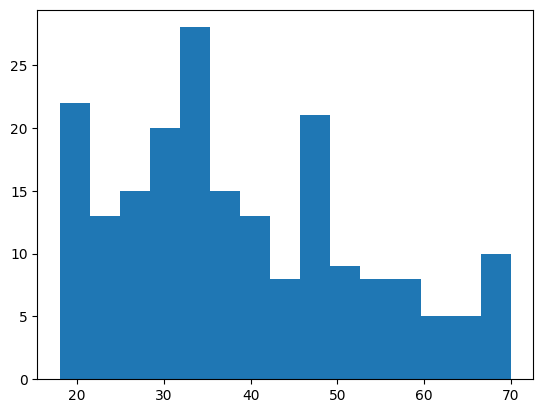

In [8]:
plt.hist(df["Age"], bins = 15)
plt.show()

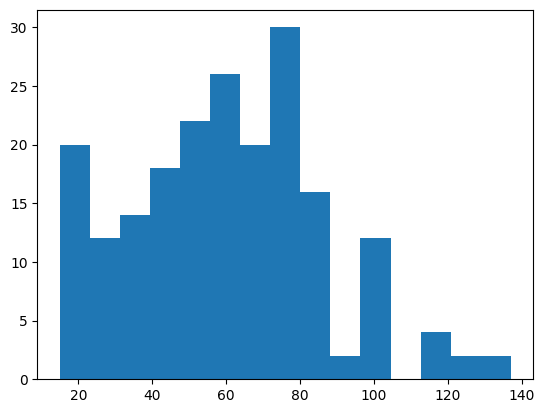

In [9]:
plt.hist(df["Annual Income (k$)"], bins = 15)
plt.show()

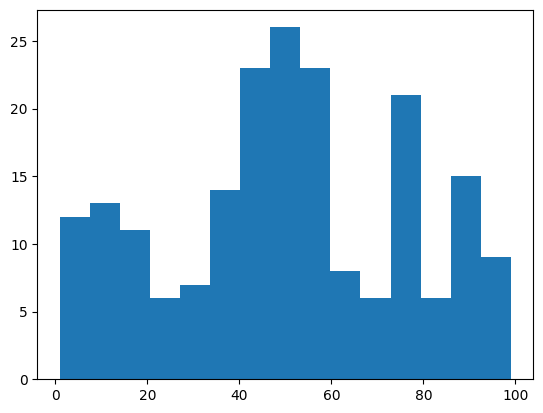

In [10]:
plt.hist(df["Spending Score (1-100)"], bins = 15)
plt.show()

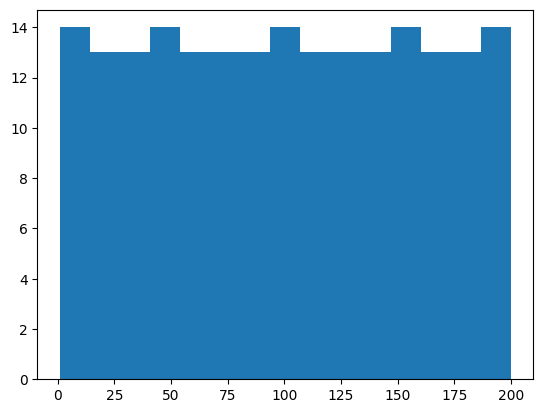

In [11]:
plt.hist(df["CustomerID"], bins = 15)
plt.show()

In [12]:
df.drop(columns= ["CustomerID"], inplace = True)
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


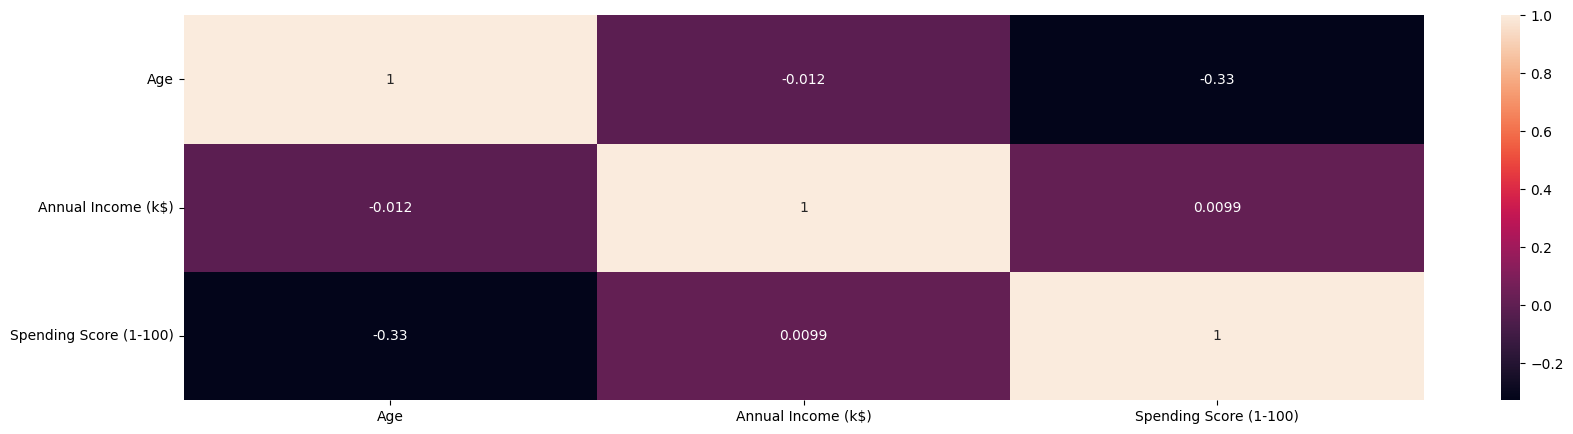

In [13]:
plt.figure(figsize = (20,5))
sns.heatmap(df.corr(numeric_only = True), annot = True)
plt.show()

In [14]:
x = df[["Annual Income (k$)", "Spending Score (1-100)"]]
x.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [15]:
from sklearn.preprocessing import StandardScaler
scale = StandardScaler()
x_scale = scale.fit_transform(x)

In [16]:
from sklearn.cluster import KMeans
k_mean = KMeans(n_clusters = 5, random_state=42)
k_mean.fit(x_scale)
df["Cluster"] = k_mean.labels_

C:\Users\agraw\Downloads\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [17]:
from scipy.cluster.hierarchy import dendrogram, linkage

z = linkage(x_scale, method = "ward")




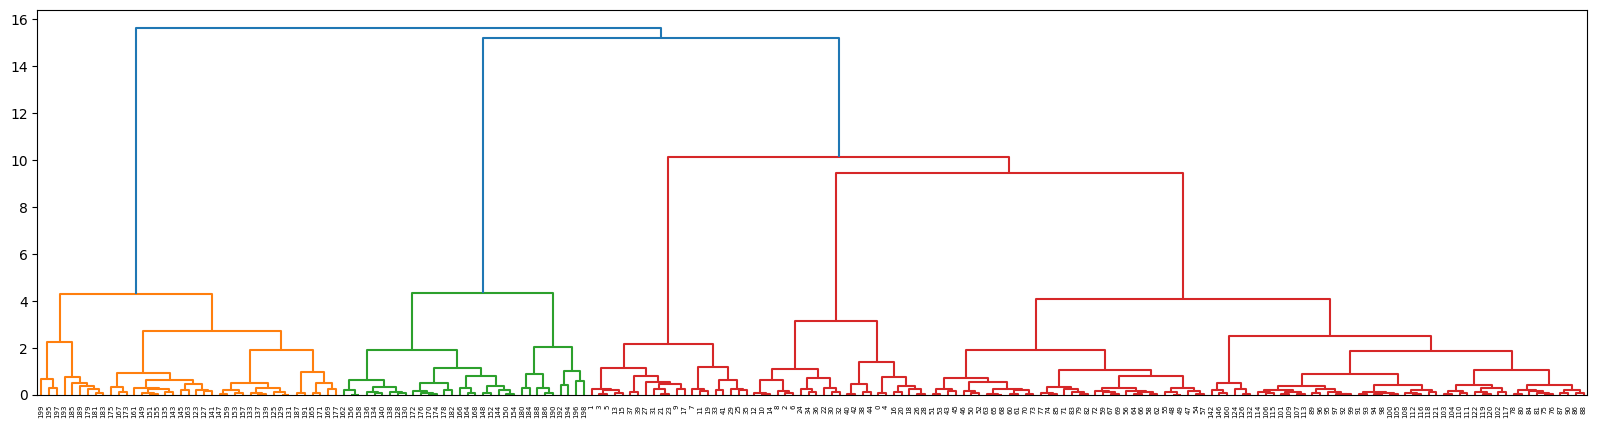

In [18]:
plt.figure(figsize = (20,5))
dendrogram(z)
plt.show()

In [19]:
from sklearn.cluster import AgglomerativeClustering
model = AgglomerativeClustering(n_clusters=5, metric="euclidean", linkage="ward")

df["cluster"] = model.fit_predict(x_scale)

In [20]:
df["cluster"]

0      4
1      3
2      4
3      3
4      4
      ..
195    1
196    0
197    1
198    0
199    1
Name: cluster, Length: 200, dtype: int64

In [21]:
from sklearn.metrics import silhouette_score
score = silhouette_score(x_scale, df["cluster"])
score

0.5538089226688662